In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import matplotlib.pyplot as plt



In [5]:
df= pd.read_csv("data/AmesHousing_engineered.csv")
df

,Order,PID,MS SubClass,Lot Shape,Land Slope,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,HouseAge,Log_LotArea
0,0.000000,0.000000,0.000000,1.098612,2,0.500,0.637681,0.166667,0.067659,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.362319,0.074608
1,0.000341,0.000102,0.000000,1.386294,2,0.625,0.644928,0.183333,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.355072,0.047118
2,0.000683,0.000104,0.000000,1.098612,2,0.625,0.623188,0.133333,0.065319,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.376812,0.058843
3,0.001024,0.000108,0.000000,1.386294,2,0.500,0.695652,0.300000,0.000000,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.304348,0.045056
4,0.001366,0.001672,0.211309,1.098612,2,0.500,0.905797,0.800000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.094203,0.056916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,0.998634,0.825655,0.302281,1.098612,2,0.625,0.811594,0.566667,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.811594,0.030551
2926,0.998976,0.825657,0.000000,1.098612,2,0.500,0.804348,0.550000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.804348,0.034839
2927,0.999317,0.825915,0.323787,1.386294,2,0.500,0.869565,0.700000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.869565,0.041838
2928,0.999659,0.827371,0.000000,1.386294,2,0.500,0.739130,0.416667,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.739130,0.039905


In [6]:
df.describe()

,Order,PID,MS SubClass,Lot Shape,Land Slope,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,HouseAge,Log_LotArea
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.0,2930.00000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.000000,2930.000000
mean,0.500000,0.391356,0.174384,1.266836,2.0,0.56715,0.720081,0.571109,0.050300,1.209529,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.272367,0.037773
std,0.288823,0.392536,0.173722,0.176377,0.0,0.11902,0.218845,0.347671,0.075194,0.164728,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.397832,0.016335
min,0.000000,0.000000,0.000000,0.405465,2.0,0.31250,0.083333,0.000000,0.000000,0.693147,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.971014,0.000509
25%,0.250000,0.004526,0.000000,1.098612,2.0,0.50000,0.594203,0.250000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.601449,0.028296
50%,0.500000,0.019036,0.162519,1.386294,2.0,0.50000,0.731884,0.716667,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.255435,0.037325
75%,0.750000,0.792181,0.257829,1.386294,2.0,0.62500,0.934783,0.900000,0.096871,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.025362,0.046821
max,1.000000,1.000000,0.551177,1.386294,2.0,0.81250,1.000000,1.000000,0.226575,1.609438,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.965580,0.074608


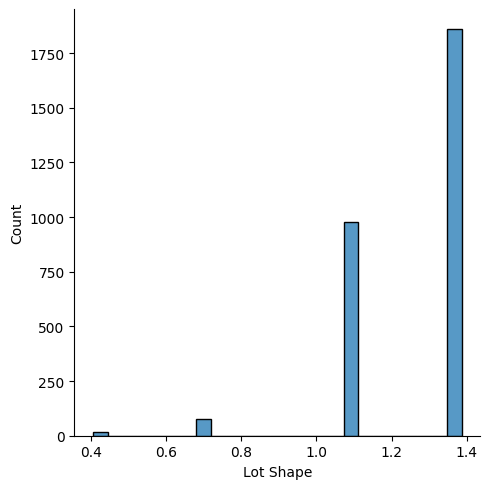

In [13]:
import seaborn as sns
sns.displot(df['Lot Shape'])

<Axes: ylabel='Lot Shape'>

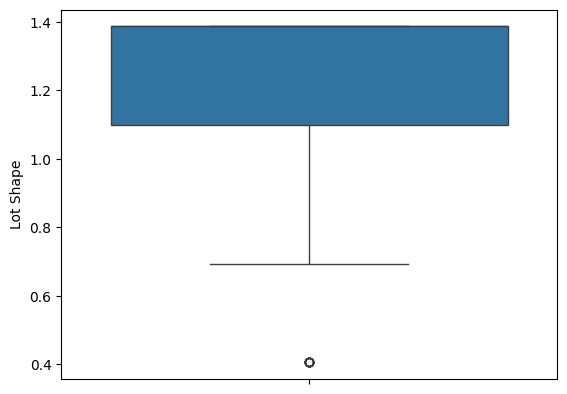

In [14]:
sns.boxplot(df['Lot Shape'])

In [15]:
#z-score
upper_limit=df['Lot Shape'].mean()+3*df['Lot Shape'].std()
lower_limit=df['Lot Shape'].mean()-3*df['Lot Shape'].std()
print(upper_limit)
print(lower_limit)

1.7959669343843736
0.7377049259434372


In [17]:
#find outliers
df.loc[(df['Lot Shape']>upper_limit) | (df['Lot Shape']<lower_limit)]

,Order,PID,MS SubClass,Lot Shape,Land Slope,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,HouseAge,Log_LotArea
15,0.005121,0.001903,0.211309,0.693147,2,0.5,0.949275,0.883333,0.226575,1.609438,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.050725,0.074608
60,0.020485,0.004249,0.211309,0.693147,2,0.5,0.913043,0.800000,0.068826,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.086957,0.072699
64,0.021850,0.004328,0.211309,0.693147,2,0.5,0.913043,0.800000,0.018576,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.086957,0.069814
99,0.033800,0.014376,0.000000,0.693147,2,0.5,0.992754,0.983333,0.226575,1.609438,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.007246,0.014400
205,0.069990,0.784421,0.344840,0.693147,2,0.5,0.659420,0.216667,0.000000,0.693147,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.340580,0.032973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2791,0.952885,0.792333,0.211309,0.693147,2,0.5,0.920290,0.816667,0.088469,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.920290,0.037467
2793,0.953568,0.792335,0.000000,0.693147,2,0.5,0.934783,0.866667,0.105486,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.934783,0.061106
2797,0.954933,0.792377,0.211309,0.693147,2,0.5,0.898551,0.783333,0.000000,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.898551,0.074608
2806,0.958006,0.792639,0.211309,0.693147,2,0.5,0.956522,0.916667,0.000000,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.956522,0.050550


In [22]:
#triming: deleting outliers
nw_df=df.loc[(df['Lot Shape']<upper_limit) & (df['Lot Shape']>lower_limit)]
print('old data',len(df))
print('new data',len(nw_df))
print('outliers',len(df)-len(nw_df))

old data 2930
new data 2838
outliers 92


In [23]:
#capping : replacing outliers with max or min value
nw_df=df.copy()
nw_df.loc[df['Lot Shape']>upper_limit,'Lot Shape']=upper_limit
nw_df.loc[df['Lot Shape']<lower_limit,'Lot Shape']=lower_limit
print('old data',len(df))
print('new data',len(nw_df))
print('outliers',len(df)-len(nw_df))

old data 2930
new data 2930
outliers 0


In [27]:
#IQR
q1=df['Lot Shape'].quantile(0.25)
q3=df['Lot Shape'].quantile(0.75)
iqr=q3-q1
print(q1,q3,iqr)
upper_limit=df['Lot Shape'].quantile(0.75)+1.5*(df['Lot Shape'].quantile(0.75)-df['Lot Shape'].quantile(0.25))
lower_limit=df['Lot Shape'].quantile(0.25)-1.5*(df['Lot Shape'].quantile(0.75)-df['Lot Shape'].quantile(0.25))
print(upper_limit)
print(lower_limit)

1.0986122886681096 1.3862943611198906 0.287682072451781
1.817817469797562
0.667089179990438
